In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import files

In [4]:
total_production = files.upload()

Saving total-production.csv to total-production (1).csv


In [143]:
df = pd.read_csv("total-production.csv")
coffee_production = df.T
coffee_production.columns= coffee_production.iloc[0]
coffee_production.drop("total_production", inplace=True)

# Meshgrid - Single Figure Report on Brazil's Place in Global Coffee Market

* Create a Meshgrid Layout to combine our findings from our first project into a single report.
* We want the two donut charts representing Brazil's production share in 1990 and 2018 in the top third of the figure.
* The stackplot comparing Brazil to the rest of the world in the center of the figure.
* In the bottom third a bar chart showing the total production of our top 5 countries, as well as a bar for other. Also include a pie chart showing the composition of the same data plotted in the bar chart.
* Look up the country colors for our top 5 countries and color them accordingly. For 'other' category, color these grey.
* Consider setting rcParams to turn top and right borders off.
* Save the report out as an image.

In [144]:
coffee_production.head()

total_production,Angola,Bolivia (Plurinational State of),Brazil,Burundi,Ecuador,Indonesia,Madagascar,Malawi,Papua New Guinea,Paraguay,...,Panama,Sierra Leone,Sri Lanka,Thailand,Togo,Trinidad & Tobago,Uganda,Venezuela,Viet Nam,Yemen
1990,50.345,122.777,27285.6286,487.393,1503.815,7441.383,982.447,104.628,962.841,130.627,...,214.987,42.783,95.87,757.017,161.308,14.581,1955.009,1122.477,1310.288,0.0
1991,79.331,103.536,27293.4934,667.199,2123.824,8493.196,932.513,124.286,746.816,79.653,...,192.532,54.379,81.549,1468.936,432.652,17.792,2088.001,940.704,1437.848,0.0
1992,77.52,120.235,34603.3542,620.238,1185.48,5569.478,1121.684,137.161,900.111,54.291,...,196.978,39.084,53.181,1254.945,85.648,14.328,2185.074,1215.298,2340.447,0.0
1993,32.608,50.823,28166.9786,393.354,2069.007,6743.288,441.859,62.111,1019.481,70.046,...,142.066,37.451,53.79,1275.201,194.939,16.079,3141.706,1332.881,3020.216,0.0
1994,76.802,116.944,28192.047,664.143,2375.766,5367.878,641.372,84.112,1138.659,24.689,...,248.313,72.738,42.448,1399.135,176.296,18.435,2392.753,988.996,3631.609,0.0


In [129]:
plt.rcParams.keys()

KeysView(RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'b

In [145]:
axes_settings = {"spines.top": False,
                 "spines.right": False,
                 # "facecolor":(0,0,0,.1),
                 # "facealpha" : .4 ,
                 # "grid" : True,
                 # "grid.axis":'y'
                 }
plt.rc("axes", **axes_settings)

### Data Prep

In [146]:
coffee_production = coffee_production.astype("float64")
coffee_production.head()

total_production,Angola,Bolivia (Plurinational State of),Brazil,Burundi,Ecuador,Indonesia,Madagascar,Malawi,Papua New Guinea,Paraguay,...,Panama,Sierra Leone,Sri Lanka,Thailand,Togo,Trinidad & Tobago,Uganda,Venezuela,Viet Nam,Yemen
1990,50.345,122.777,27285.6286,487.393,1503.815,7441.383,982.447,104.628,962.841,130.627,...,214.987,42.783,95.870,757.017,161.308,14.581,1955.009,1122.477,1310.288,0.0
1991,79.331,103.536,27293.4934,667.199,2123.824,8493.196,932.513,124.286,746.816,79.653,...,192.532,54.379,81.549,1468.936,432.652,17.792,2088.001,940.704,1437.848,0.0
1992,77.520,120.235,34603.3542,620.238,1185.480,5569.478,1121.684,137.161,900.111,54.291,...,196.978,39.084,53.181,1254.945,85.648,14.328,2185.074,1215.298,2340.447,0.0
1993,32.608,50.823,28166.9786,393.354,2069.007,6743.288,441.859,62.111,1019.481,70.046,...,142.066,37.451,53.790,1275.201,194.939,16.079,3141.706,1332.881,3020.216,0.0
1994,76.802,116.944,28192.0470,664.143,2375.766,5367.878,641.372,84.112,1138.659,24.689,...,248.313,72.738,42.448,1399.135,176.296,18.435,2392.753,988.996,3631.609,0.0


In [147]:
coffee_production["rest_of_world"] = coffee_production.drop(columns="Brazil", axis = 1).sum(axis=1)

In [148]:
brazil_vs_others = pd.concat([coffee_production["Brazil"], coffee_production["rest_of_world"]], axis = 1)
brazil_vs_others.head()

,Brazil,rest_of_world
1990,27285.6286,65944.431
1991,27293.4934,73973.191
1992,34603.3542,63922.545
1993,28166.9786,63597.643
1994,28192.0470,65121.147


In [149]:
brazil_vs_others.loc["2018"]

,2018
Brazil,62924.8836
rest_of_world,108011.8541


In [151]:
top_5_countries_2018 = coffee_production.T.drop(["rest_of_world"])["2018"].sort_values(ascending=False).iloc[:5]
top_5_countries_2018


,2018
total_production,
Brazil,62924.8836
Viet Nam,31174.0742
Colombia,13857.9620
Indonesia,9417.5942
Ethiopia,7776.2234


In [152]:
top_5_countries_2018.loc["Rest_of_World"] = coffee_production.T.loc["rest_of_world","2018"]
top_5_countries_2018

,2018
total_production,
Brazil,62924.8836
Viet Nam,31174.0742
Colombia,13857.9620
Indonesia,9417.5942
Ethiopia,7776.2234
Rest_of_World,108011.8541


In [154]:
brazil_vs_others.index = pd.to_datetime(brazil_vs_others.index)
brazil_vs_others.index

DatetimeIndex(['1990-01-01', '1991-01-01', '1992-01-01', '1993-01-01',
               '1994-01-01', '1995-01-01', '1996-01-01', '1997-01-01',
               '1998-01-01', '1999-01-01', '2000-01-01', '2001-01-01',
               '2002-01-01', '2003-01-01', '2004-01-01', '2005-01-01',
               '2006-01-01', '2007-01-01', '2008-01-01', '2009-01-01',
               '2010-01-01', '2011-01-01', '2012-01-01', '2013-01-01',
               '2014-01-01', '2015-01-01', '2016-01-01', '2017-01-01',
               '2018-01-01'],
              dtype='datetime64[ns]', freq=None)

In [155]:
brazil_vs_others.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 29 entries, 1990-01-01 to 2018-01-01
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Brazil         29 non-null     float64
 1   rest_of_world  29 non-null     float64
dtypes: float64(2)
memory usage: 696.0 bytes


In [273]:
brazil_vs_others.iloc[0].div(brazil_vs_others.iloc[0].sum())

,1990-01-01
Brazil,0.29267
rest_of_world,0.70733


In [279]:
brazil_vs_others.iloc[-1].div(brazil_vs_others.iloc[-1].sum())*100

,2018-01-01
Brazil,36.811796
rest_of_world,63.188204


### Meshgrid Layout

In [250]:
top_5_countries_2018.values

array([ 62924.8836,  31174.0742,  13857.962 ,   9417.5942,   7776.2234,
       108011.8541])

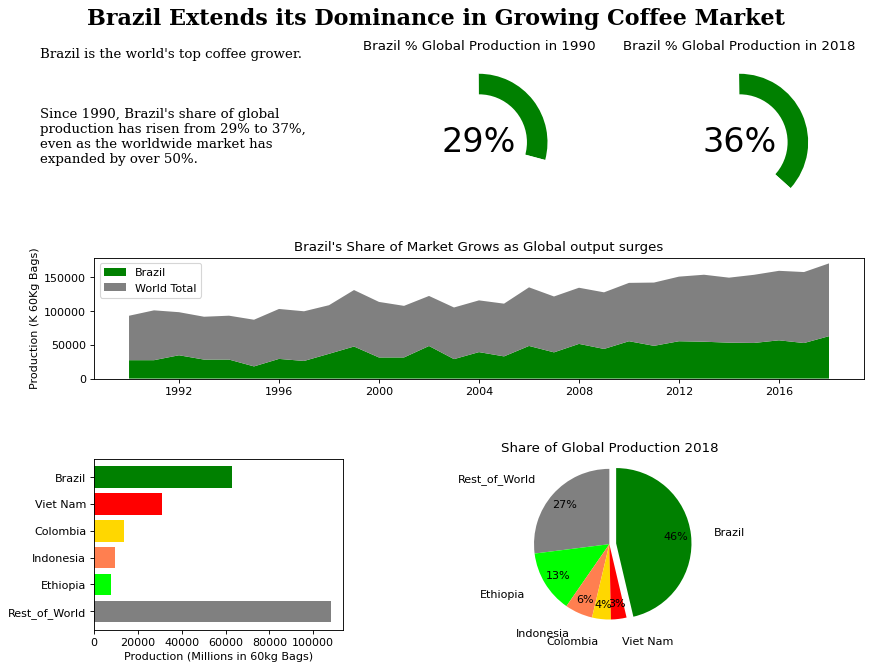

In [337]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize = (11,8.5))
plt.style.use("default")
nrows = 12
ncols = 6
gs = gridspec.GridSpec(nrows , ncols)

fig.suptitle("Brazil Extends its Dominance in Growing Coffee Market",
             fontsize = 20 ,
             fontweight = "bold" ,
             fontfamily = "serif")

fig.text(0.05,0.73,
'''Brazil is the world's top coffee grower.



Since 1990, Brazil's share of global
production has risen from 29% to 37%,
even as the worldwide market has
expanded by over 50%.
''',
         fontdict={"size":12 , "weight": "light" , "family": "serif"})
################################################################################
ax1 = fig.add_subplot(gs[0:4,2:4])

ax1.pie(x = brazil_vs_others.iloc[0] ,
        startangle=-15,
        colors = ["green" , "white"],
        pctdistance = .85)
donut_hole = plt.Circle(xy = (0,0), radius = 0.70 , fc = "white")
ax1.add_artist(donut_hole)
ax1.text(0,0,"29%" , ha ="center" , va = "center" , fontsize = 30)
ax1.set_title("Brazil % Global Production in 1990")
################################################################################
ax2 = fig.add_subplot(gs[0:4 , 4:])
ax2.pie(x = brazil_vs_others.iloc[-1] ,
        startangle=-42,
        colors = ["green" , "white"],
        pctdistance = .85)
donut_hole = plt.Circle(xy = (0,0), radius = 0.70 , fc = "white")
ax2.add_artist(donut_hole)
ax2.text(0,0,"36%" , ha ="center" , va = "center" , fontsize = 30)
ax2.set_title("Brazil % Global Production in 2018")
################################################################################
ax3 = fig.add_subplot(gs[4:7 , :])
ax3.set_title("Brazil's Share of Market Grows as Global output surges")
ax3.stackplot(brazil_vs_others.index ,
              brazil_vs_others["Brazil"] ,
              brazil_vs_others["rest_of_world"] , colors = ["green" , "gray"])
ax3.legend(["Brazil" , "World Total"])
ax3.set_ylabel("Production (K 60Kg Bags)")
################################################################################
ax4 = fig.add_subplot(gs[8: ,0:2])
ax4.barh(y = top_5_countries_2018.index[::-1] ,
         width = top_5_countries_2018.values[::-1],
         color = ["green" , "red" , "gold" , "coral" , "lime" , "gray"][::-1]
         )
ax4.set_xlabel("Production (Millions in 60kg Bags)")
################################################################################
ax5 = fig.add_subplot(gs[8: , 2:6])
ax5.pie(x = top_5_countries_2018 ,
        radius =1.1,
        startangle = 90,
        labels = list(top_5_countries_2018.index[::-1]) ,
        labeldistance=1.3,
        autopct = "%1.0f%%",
        pctdistance= 0.8,
        explode=[0 , 0 , 0 , 0 , 0 ,0.1],
        colors = ["green" , "red" , "gold" , "coral" , "lime" , "gray"][::-1]
        )
ax5.set_title("Share of Global Production 2018")
################################################################################
fig.savefig("brazil_stats.png" , bbox_inches = "tight" , facecolor = "white")
plt.tight_layout()

# Subplots

* Read in `prices-paid-to-growers.csv` and create a subplot grid of histograms showing the distribution of prices paid to the countries Brazil, Colombia, Ethiopia, and one for all other nations.

In [308]:
growers_upload = files.upload()

Saving prices-paid-to-growers.csv to prices-paid-to-growers.csv


In [311]:
prices_paid_to_growers = pd.read_csv("prices-paid-to-growers.csv").T.drop(9, axis=1)
prices_paid_to_growers.head()

,0,1,2,3,4,5,6,7,8,10,11,12
prices_paid_to_growers,Colombia,Dominican Republic,El Salvador,Guatemala,Honduras,India,Uganda,Brazil,Ethiopia,India,Togo,Uganda
1990,1.534724,1.458168,1.116194,1.204956,1.11147,1.473558,0.337598,1.199223,1.348565,0.978921,0.645267,0.166486
1991,1.48179,1.382845,0.983322,1.270086,1.238947,1.358371,0.654322,0.97115,1.505322,0.897289,0.632307,0.26143
1992,1.204656,1.027841,0.682322,0.888099,0.886057,1.191159,0.441397,0.997768,1.351128,0.877945,0.658494,0.197653
1993,1.106477,1.172704,0.780397,0.914552,0.828746,1.278669,0.552298,1.167263,1.362442,0.975912,0.499857,0.259737


In [312]:
prices_paid_to_growers.columns= prices_paid_to_growers.iloc[0]

prices_paid_to_growers.drop("prices_paid_to_growers", inplace=True)

prices_paid_to_growers["Other Nations"] =  prices_paid_to_growers.drop(["Colombia", "Brazil", "Ethiopia"], axis=1).mean(axis=1)

In [313]:
prices_paid_to_growers.head()

prices_paid_to_growers,Colombia,Dominican Republic,El Salvador,Guatemala,Honduras,India,Uganda,Brazil,Ethiopia,India,Togo,Uganda,Other Nations
1990,1.534724,1.458168,1.116194,1.204956,1.11147,1.473558,0.337598,1.199223,1.348565,0.978921,0.645267,0.166486,0.943624
1991,1.48179,1.382845,0.983322,1.270086,1.238947,1.358371,0.654322,0.97115,1.505322,0.897289,0.632307,0.26143,0.964325
1992,1.204656,1.027841,0.682322,0.888099,0.886057,1.191159,0.441397,0.997768,1.351128,0.877945,0.658494,0.197653,0.761219
1993,1.106477,1.172704,0.780397,0.914552,0.828746,1.278669,0.552298,1.167263,1.362442,0.975912,0.499857,0.259737,0.806986
1994,1.898327,2.478234,2.191177,1.662711,1.800576,1.73081,1.666651,2.52911,2.418234,1.246437,0.573784,0.919709,1.585565


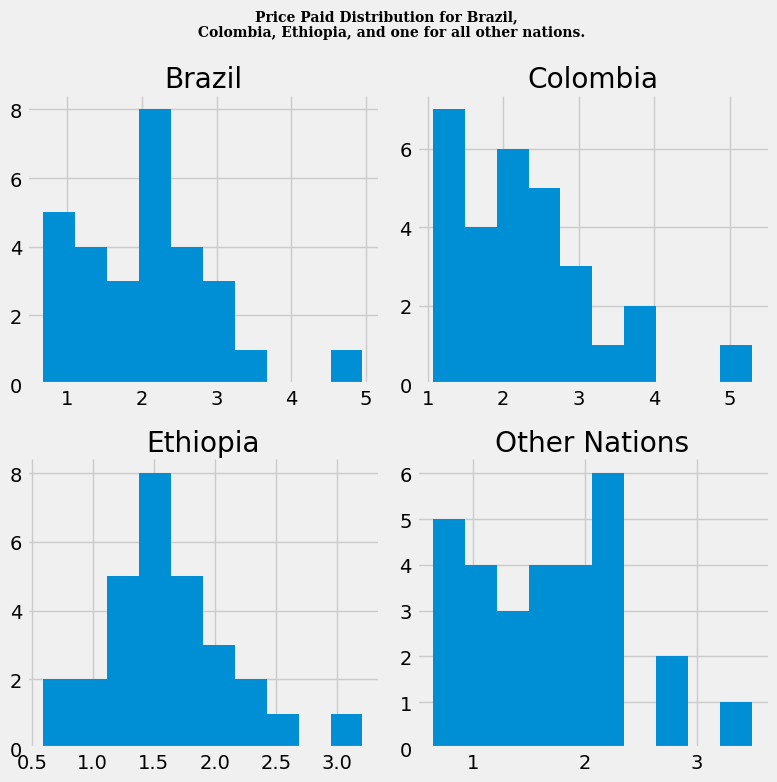

In [329]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize = (8,8))
plt.style.use("fivethirtyeight")
nrows = 4
ncols = 4
gs = gridspec.GridSpec(nrows , ncols)

fig.suptitle("Price Paid Distribution for Brazil, \n Colombia, Ethiopia, and one for all other nations.",
             fontsize = 10 ,
             fontweight = "bold" ,
             fontfamily = "serif")

ax1 = fig.add_subplot(gs[0:2 , 0:2])
ax1.hist(prices_paid_to_growers["Brazil"])
ax1.set_title("Brazil")

ax2 = fig.add_subplot(gs[0:2 , 2:4])
ax2.hist(prices_paid_to_growers["Colombia"] , )
ax2.set_title("Colombia")

ax3 = fig.add_subplot(gs[2:4 , 0:2])
ax3.hist(prices_paid_to_growers["Ethiopia"])
ax3.set_title("Ethiopia")

ax4 = fig.add_subplot(gs[2:4 , 2:4])
ax4.hist(prices_paid_to_growers["Other Nations"])
ax4.set_title("Other Nations")

plt.tight_layout()